1. Load the Best Model

In [4]:
import time
import joblib

start = time.time()

best_model = joblib.load("../models/best_fraud_model.pkl")

print("Loaded in", time.time() - start, "seconds")

Loaded in 5.8563854694366455 seconds


In [5]:
import os

os.listdir("../data/processed")

['creditcard_processed.csv', 'fraud_processed.csv']

2. Built-in Feature Importance

In [6]:
import pandas as pd

df = pd.read_csv("../data/processed/fraud_processed.csv")

print(df.shape)
df.head()

(129146, 202)


,user_id,signup_time,purchase_time,purchase_value,device_id,age,ip_address,class,lower_bound_ip_address,upper_bound_ip_address,...,country_United States,country_Uruguay,country_Uzbekistan,country_Vanuatu,country_Venezuela,country_Viet Nam,country_Virgin Islands (U.S.),country_Yemen,country_Zambia,country_Zimbabwe
0,247547,2015-06-28 03:00:34,2015-08-09 03:57:29,0.549607,KIXYSVCHIPQBR,-0.363124,16778864,0,16778240.0,16779263.0,...,False,False,False,False,False,False,False,False,False,False
1,220737,2015-01-28 14:21:11,2015-02-11 20:28:28,-1.197335,PKYOWQKWGJNJI,0.101168,16842045,0,16809984.0,16842751.0,...,False,False,False,False,False,False,False,False,False,False
2,390400,2015-03-19 20:49:09,2015-04-11 23:41:23,0.385831,LVCSXLISZHVUO,-0.479197,16843656,0,16843264.0,16843775.0,...,False,False,False,False,False,False,False,False,False,False
3,69592,2015-02-24 06:11:57,2015-05-23 16:40:14,0.986342,UHAUHNXXUADJE,-0.363124,16938732,0,16924672.0,16941055.0,...,False,False,False,False,False,False,False,False,False,False
4,174987,2015-07-07 12:58:11,2015-11-03 04:04:30,0.767974,XPGPMOHIDRMGE,0.449387,16971984,0,16941056.0,16973823.0,...,False,False,False,False,False,False,False,False,False,False


In [7]:
print(df.columns)

Index(['user_id', 'signup_time', 'purchase_time', 'purchase_value',
       'device_id', 'age', 'ip_address', 'class', 'lower_bound_ip_address',
       'upper_bound_ip_address',
       ...
       'country_United States', 'country_Uruguay', 'country_Uzbekistan',
       'country_Vanuatu', 'country_Venezuela', 'country_Viet Nam',
       'country_Virgin Islands (U.S.)', 'country_Yemen', 'country_Zambia',
       'country_Zimbabwe'],
      dtype='str', length=202)


In [8]:
X = df.drop(columns=[
    'class',
    'device_id',
    'signup_time',
    'purchase_time'
])

print("Features:", len(X.columns))
print("Importances:", len(best_model.feature_importances_))

Features: 198
Importances: 198


In [9]:
# Create target
y = df['class']

print(X.shape)
print(y.shape)

(129146, 198)
(129146,)


In [10]:
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
10,device_frequency,0.404390
6,time_since_signup,0.197735
3,ip_address,0.036222
4,lower_bound_ip_address,0.033706
5,upper_bound_ip_address,0.033473
2,age,0.033002
1,purchase_value,0.032676
0,user_id,0.031590
7,hour_of_day,0.027586
11,source_Direct,0.021589


3. Visualize Top 10 Features

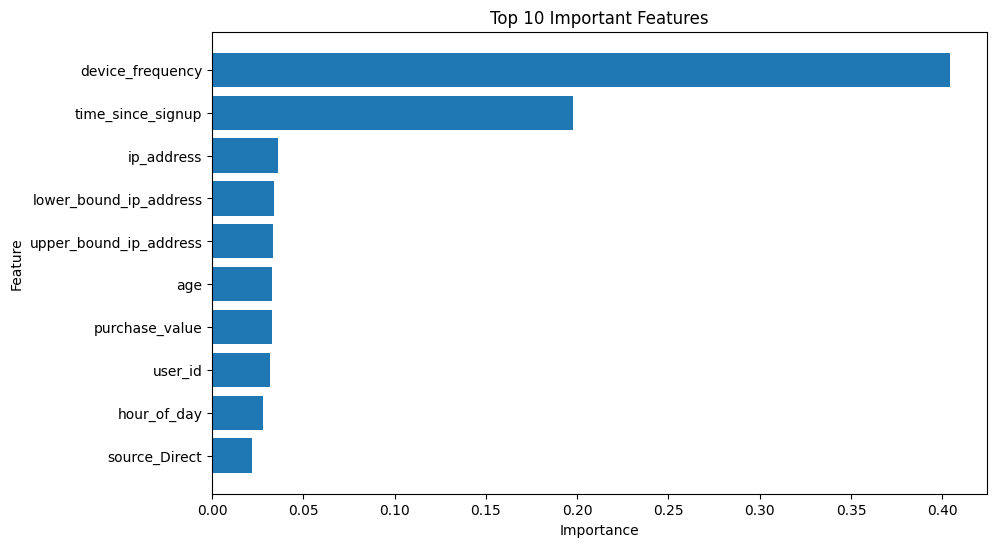

In [11]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance['Feature'].head(10),
    feature_importance['Importance'].head(10)
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()

plt.show()

## Feature Importance Interpretation

The feature importance analysis from the Random Forest model reveals that **device_frequency** is the most influential predictor of fraudulent transactions, contributing approximately 40% of the model's decision-making power. This suggests that the frequency with which a device is used plays a critical role in identifying suspicious behavior. Devices associated with unusually high transaction activity may indicate fraudulent usage.

The second most important feature is **time_since_signup**, accounting for about 20% of the overall importance. This indicates that transactions occurring shortly after account creation are more likely to be fraudulent. Fraudsters often create accounts and attempt transactions immediately before detection mechanisms can identify them.

Several other features, including **ip_address**, **lower_bound_ip_address**, and **upper_bound_ip_address**, also contribute to fraud detection, although their impact is considerably smaller. Their presence among the top features suggests that geographic and network-related information provides useful signals for identifying suspicious transactions.

Features such as **purchase_value**, **age**, and **hour_of_day** have moderate importance, indicating that transaction amount, customer demographics, and transaction timing contribute to the model's predictions but are less influential than behavioral features.

Interestingly, **user_id** appears among the top features. Since user identifiers are unique values rather than meaningful behavioral attributes, this may indicate potential data leakage or that the model is learning patterns specific to individual users rather than general fraud behavior. In a production environment, user identifiers should typically be removed from the feature set.

Overall, the model relies primarily on behavioral features (**device_frequency** and **time_since_signup**) rather than demographic characteristics, which aligns with common fraud detection patterns where unusual activity and account behavior are stronger indicators of fraud than personal attributes.

4. Create SHAP Explainer

In [12]:
import shap

c:\Users\Administrator\projects\fraud-detection-week5-6\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [14]:
print(type(df))

<class 'pandas.DataFrame'>


In [15]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(103316, 198)
(25830, 198)
(103316,)
(25830,)


In [16]:
print("Model features:", len(best_model.feature_importances_))
print("X_test features:", X_test.shape[1])

Model features: 198
X_test features: 198


In [26]:
X_test_sample = X_test.sample(
    n=100,
    random_state=42

)

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_sample)

In [27]:
#For binary classification:
#shap_values = shap_values[1]


In [28]:
import numpy as np

print(type(shap_values))
print(np.array(shap_values).shape)

<class 'numpy.ndarray'>
(100, 198, 2)


In [30]:
print(X_test_sample.shape)

print(type(shap_values))
print(len(shap_values))

print(shap_values[0].shape)
print(shap_values[1].shape)

(100, 198)
<class 'numpy.ndarray'>
100
(198, 2)
(198, 2)


5. SHAP Summary Plot

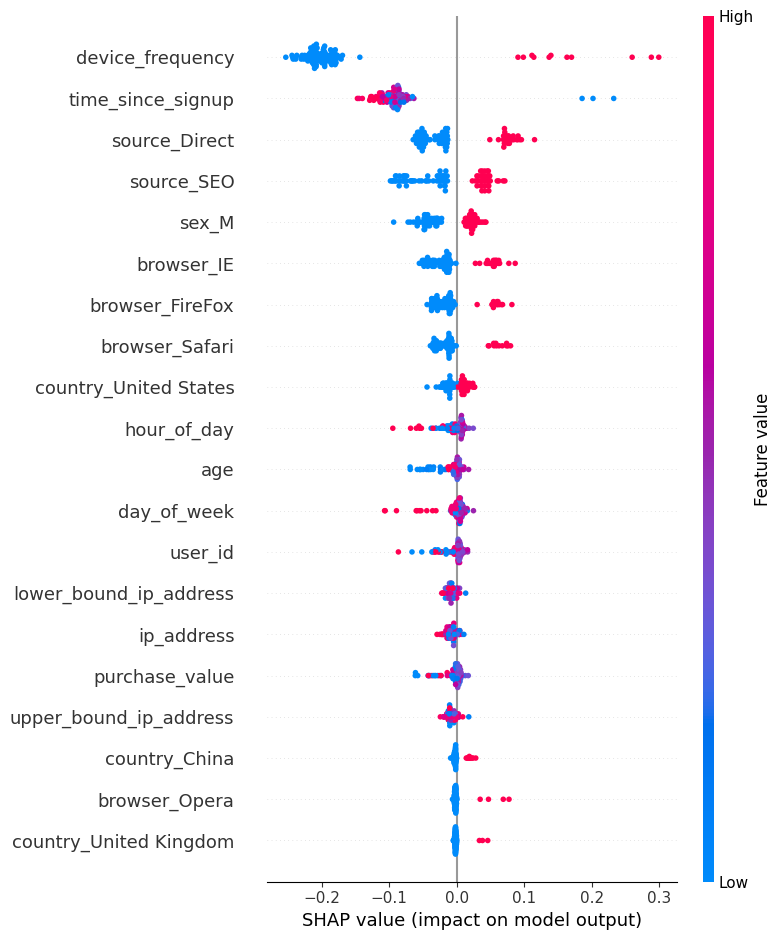

In [32]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test_sample
)

## SHAP Summary Plot Interpretation

The SHAP Summary Plot provides a global explanation of the Random Forest model by showing both feature importance and the direction of each feature's impact on fraud predictions.

### Key Findings

#### 1. Device Frequency is the Strongest Fraud Indicator

The most influential feature is **device_frequency**. High values of device frequency (shown in red) are associated with positive SHAP values, pushing predictions toward the fraud class. Conversely, low device frequency values (shown in blue) contribute negatively to fraud predictions.

This suggests that devices generating unusually high numbers of transactions are significantly more likely to be involved in fraudulent activities.

#### 2. Time Since Signup Strongly Influences Fraud Risk

**time_since_signup** is the second most important feature. Lower values of time since signup tend to increase fraud probability, while longer periods between account creation and purchase reduce fraud risk.

This pattern indicates that fraudsters often create accounts and perform transactions shortly afterward, whereas legitimate users typically exhibit a longer delay between registration and purchasing.

#### 3. Traffic Source Contributes to Fraud Detection

Features such as **source_Direct** and **source_SEO** have notable effects on model predictions. Transactions originating from certain acquisition channels appear more likely to be classified as fraudulent.

This suggests that user acquisition channels contain useful behavioral signals that can help identify suspicious activity.

#### 4. Browser Type Provides Additional Fraud Signals

Browser-related features such as **browser_IE**, **browser_FireFox**, **browser_Safari**, and **browser_Opera** influence fraud predictions. Certain browsers are associated with increased fraud risk, although their impact is smaller than behavioral features.

These patterns may reflect differences in user behavior or browser preferences among fraudulent users.

#### 5. Geographic Information Plays a Moderate Role

Country-related variables, including **country_United States**, **country_China**, and **country_United Kingdom**, contribute to the model's decisions. While geographic features are not the primary drivers of fraud detection, they provide additional context that helps distinguish legitimate and fraudulent transactions.

#### 6. Transaction Timing and Demographics Have Limited Impact

Features such as **hour_of_day**, **day_of_week**, and **age** show relatively small SHAP values compared to the top-ranked features. This indicates that transaction behavior and device usage patterns are more informative for fraud detection than customer demographics or transaction timing alone.

### Comparison with Built-in Feature Importance

The SHAP analysis is broadly consistent with the Random Forest feature importance results. Both approaches identify **device_frequency** and **time_since_signup** as the most influential predictors of fraud. However, SHAP provides additional insight by showing whether high or low feature values increase fraud risk and by quantifying the direction of each feature's contribution.

### Top 5 Drivers of Fraud Predictions

1. Device Frequency
2. Time Since Signup
3. Source (Direct Traffic)
4. Source (SEO Traffic)
5. Browser Type

### Business Insight

The results indicate that fraud is primarily driven by behavioral patterns rather than demographic characteristics. Accounts that make transactions shortly after registration and devices generating unusually high transaction activity represent the strongest fraud signals. Therefore, fraud prevention strategies should focus on monitoring user behavior, transaction velocity, and account age rather than relying heavily on customer demographics.

6. SHAP Bar Plot

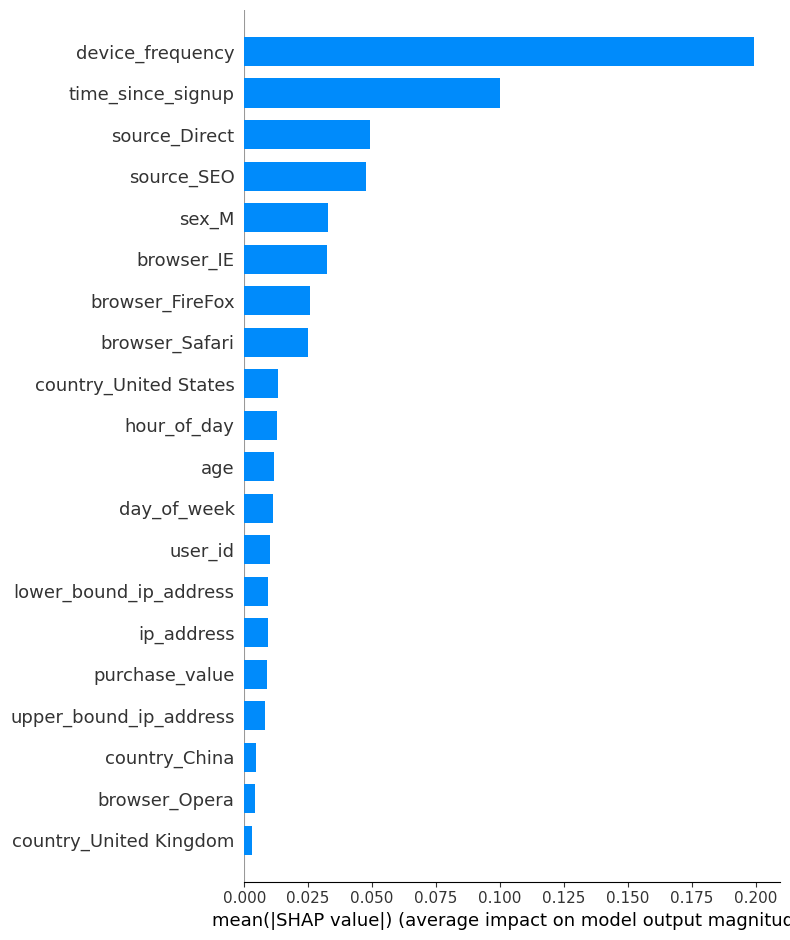

In [34]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test_sample,
    plot_type="bar"
)

## SHAP Feature Importance Bar Plot Interpretation

The SHAP Feature Importance Bar Plot ranks features according to their average absolute impact on the model's predictions. Unlike the SHAP summary plot, which shows both the magnitude and direction of feature effects, this visualization focuses solely on overall importance.

### Key Findings

#### 1. Device Frequency is the Most Important Feature

**device_frequency** has the highest average SHAP value, making it the most influential predictor of fraud. Its importance is substantially greater than all other features, indicating that the number of transactions associated with a device is the strongest signal used by the model.

This suggests that devices exhibiting unusually high transaction activity are significantly more likely to be involved in fraudulent behavior.

#### 2. Time Since Signup is the Second Most Important Feature

**time_since_signup** ranks as the second most influential feature. The strong importance of this variable indicates that the time elapsed between account registration and purchase is a critical factor in fraud detection.

Fraudulent accounts often perform transactions shortly after creation, whereas legitimate customers typically demonstrate longer account histories before making purchases.

#### 3. Traffic Source Provides Valuable Fraud Signals

Features related to acquisition channels, particularly **source_Direct** and **source_SEO**, are among the top contributors to model predictions. This suggests that the method through which users arrive at the platform contains meaningful information about fraud risk.

#### 4. Browser Characteristics Influence Predictions

Browser-related features such as **browser_IE**, **browser_FireFox**, and **browser_Safari** contribute moderately to fraud detection. While their impact is lower than behavioral features, browser information helps the model distinguish between legitimate and suspicious transactions.

#### 5. Geographic Features Have Supporting Importance

Country-based variables such as **country_United States**, **country_China**, and **country_United Kingdom** appear among the important features. These variables provide additional context regarding transaction origin and contribute to identifying geographic fraud patterns.

#### 6. Demographic and Timing Features Have Lower Impact

Features such as **age**, **hour_of_day**, and **day_of_week** have relatively small SHAP importance values. This indicates that fraud detection is driven more by user behavior and transaction patterns than by demographic characteristics or transaction timing alone.

### Comparison with Random Forest Feature Importance

The SHAP feature importance results are highly consistent with the Random Forest feature importance analysis. Both methods identify **device_frequency** and **time_since_signup** as the dominant predictors of fraud. This consistency increases confidence that the model is learning meaningful fraud-related patterns rather than relying on random correlations.

### Top 5 Most Important Features

1. Device Frequency
2. Time Since Signup
3. Source (Direct Traffic)
4. Source (SEO Traffic)
5. Sex (Male)

### Overall Insight

The SHAP feature importance analysis demonstrates that behavioral indicators are the primary drivers of fraud detection. Features describing how users interact with the platform, particularly transaction frequency and account age, have a much greater influence on predictions than demographic or geographic characteristics. This suggests that fraud prevention efforts should focus on monitoring behavioral anomalies and suspicious transaction patterns.

7. Find True Positive
correctly predicted fraud

In [35]:
#One True Positive

y_pred = best_model.predict(X_test)

tp_indices = X_test[
    (y_test == 1) &
    (y_pred == 1)
].index

tp_indices[:5]

Index([118326, 42579, 124790, 109197, 78326], dtype='int64')

In [45]:
y_pred_sample = best_model.predict(X_test_sample)

tp_indices_sample = X_test_sample[
    (y_test.loc[X_test_sample.index] == 1) &
    (y_pred_sample == 1)
].index

tp = tp_indices_sample[0]

print(tp)

97579


In [46]:
#Pick the first
#tp = tp_indices[0]

8. SHAP Force Plot for True Positive

In [47]:
shap.initjs()

tp_position = X_test_sample.index.get_loc(tp)

shap.force_plot(
    explainer.expected_value[1],
    shap_values[tp_position, :, 1],
    X_test_sample.loc[tp]
)

## SHAP Force Plot Interpretation – True Positive

### Prediction Outcome

This transaction was correctly classified as fraudulent (True Positive) with a predicted fraud score of approximately **0.97**. The model showed very high confidence in its prediction.

### Features Increasing Fraud Risk

The SHAP force plot shows that the following features pushed the prediction strongly toward fraud:

- **device_frequency = 3.131**
  - This was the strongest contributor to the fraud prediction.
  - The high device frequency suggests that the device was associated with multiple transactions, a common characteristic of fraudulent activity.

- **time_since_signup = -1.574**
  - A short time between account registration and transaction increased the fraud risk.
  - This aligns with common fraud patterns where attackers create accounts and quickly attempt transactions.

- **browser_FireFox = 1**
  - The use of Firefox contributed positively to the fraud prediction for this specific transaction.
  - This does not mean Firefox users are fraudulent, but rather that the model learned patterns in the training data where this browser was more frequently associated with fraudulent transactions.

### Features Reducing Fraud Risk

- **user_id = 3.781e+5**
  - This feature pushed the prediction slightly toward the legitimate class.
  - However, its impact was weaker than the fraud-driving features.

### Overall Explanation

The model classified this transaction as fraudulent because the strong positive effects of **device_frequency**, **time_since_signup**, and **browser_FireFox** outweighed the small negative contribution from **user_id**. The combined effect pushed the prediction from the base value toward a final fraud score of approximately **0.97**.

### Business Insight

This result suggests that fraud detection efforts should focus on monitoring:

1. Devices with unusually high transaction frequencies.
2. Transactions occurring shortly after account creation.
3. Behavioral patterns associated with specific browsing environments.

The force plot demonstrates that the model is identifying fraud primarily through behavioral indicators rather than demographic information, which improves the explainability and practical usefulness of the fraud detection system.

9. Find False Positive
Legitimate transaction flagged as fraud.

In [ ]:
y_pred_sample = best_model.predict(X_test_sample)

fp_indices_sample = X_test_sample[
    (y_test.loc[X_test_sample.index] == 0) &
    (y_pred_sample == 1)
].index

print(fp_indices_sample[:5])

Index([112763], dtype='int64')


In [52]:
#Pick one:
fp = fp_indices_sample[0]

print(fp)

112763


In [54]:
#Get Position in Sample
fp_position = X_test_sample.index.get_loc(fp)

print(fp_position)

77


In [56]:
#Force Plot

shap.force_plot(
    explainer.expected_value[1],
    shap_values[fp_position, :, 1],
    X_test_sample.loc[fp]
)

## SHAP Force Plot Interpretation – False Positive

### Prediction Outcome

This transaction was incorrectly classified as fraudulent (False Positive). Although the transaction was actually legitimate, the model assigned a fraud score of approximately **0.51**, slightly above the classification threshold.

### Features Increasing Fraud Risk

The SHAP force plot shows several features that pushed the prediction toward fraud:

- **sex_M = 1**
  - Being in this category contributed positively to the fraud prediction.
  - However, its contribution was relatively small compared to the strongest behavioral features.

- **source_Direct = 1**
  - Transactions originating from a direct traffic source increased the predicted fraud risk.
  - The model learned from historical data that this traffic source was more frequently associated with fraudulent activity.

- **device_frequency = 0.1169**
  - Device activity contributed to the fraud prediction.
  - Although the value was not extremely high, it still pushed the model toward classifying the transaction as suspicious.

### Features Reducing Fraud Risk

Several features pushed the prediction toward the legitimate class:

- **time_since_signup = -0.1538**
  - The account age suggested more normal user behavior and reduced fraud risk.

- **source_SEO = 0**
  - This feature contributed negatively to the fraud prediction.

- **hour_of_day = 0**
  - The transaction timing appeared consistent with legitimate behavior and lowered the fraud score.

- Additional browser-related features also reduced the likelihood of fraud.

### Overall Explanation

The model was uncertain about this transaction. Positive contributions from **source_Direct**, **device_frequency**, and **sex_M** slightly outweighed the negative contributions from **time_since_signup**, **hour_of_day**, and other legitimate indicators. As a result, the final fraud score reached approximately **0.51**, leading to a fraud classification despite the transaction being legitimate.

### Business Insight

This False Positive illustrates the trade-off between fraud detection and customer experience. While the model successfully identifies many fraudulent transactions, some legitimate customers may be flagged when their behavior resembles known fraud patterns.

To reduce False Positives, the organization could:

1. Introduce additional verification steps rather than automatically blocking transactions.
2. Adjust the classification threshold based on business requirements.
3. Incorporate additional behavioral features to better distinguish legitimate users from fraudsters.

### Conclusion

The False Positive occurred because several moderate fraud indicators outweighed legitimate signals. Although the model made an incorrect prediction, the force plot shows that the decision was based on understandable patterns rather than random behavior, highlighting the usefulness of SHAP for model transparency.

10. Find False Negative
Fraud transaction missed

In [57]:
y_pred_sample = best_model.predict(X_test_sample)

fn_indices_sample = X_test_sample[
    (y_test.loc[X_test_sample.index] == 1) &
    (y_pred_sample == 0)
].index

print(fn_indices_sample[:5])

Index([91423, 109697, 61026, 89347, 38357], dtype='int64')


In [58]:
#Select one
fn = fn_indices_sample[0]

print(fn)

91423


In [59]:
#Get its position in the sample
fn_position = X_test_sample.index.get_loc(fn)

print(fn_position)

8


In [60]:
#Force plot
shap.initjs()

shap.force_plot(
    explainer.expected_value[1],
    shap_values[fn_position, :, 1],
    X_test_sample.loc[fn]
)

## SHAP Force Plot Interpretation – False Negative

### Prediction Outcome

This transaction was incorrectly classified as legitimate (False Negative). Although the transaction was actually fraudulent, the model assigned a fraud score of approximately **0.05**, which is well below the classification threshold. As a result, the fraudulent transaction was missed.

### Features Increasing Fraud Risk

Only a small number of features pushed the prediction toward fraud:

- **browser_FireFox = 1**
  - The use of Firefox contributed positively to the fraud prediction.
  - However, its influence was relatively weak and insufficient to overcome the stronger features supporting a legitimate classification.

### Features Reducing Fraud Risk

Several features strongly pushed the prediction toward the legitimate class:

- **device_frequency = -0.2599**
  - The transaction originated from a device with relatively low activity.
  - Since fraudulent transactions are often associated with unusually high device usage, this reduced the predicted fraud risk.

- **time_since_signup = 1.165**
  - The account had existed for a longer period before the transaction occurred.
  - This behavior is generally associated with legitimate customers and therefore lowered the fraud score.

- **browser_IE = 0**
  - This browser-related feature contributed toward a legitimate classification.

- **source_SEO = 0**
  - The traffic source pattern reduced the model's perception of fraud risk.

- **purchase_value = -1.1**
  - The transaction amount appeared less suspicious and further pushed the prediction toward the legitimate class.

### Overall Explanation

The model failed to detect this fraudulent transaction because several features strongly resembled normal customer behavior. In particular, the longer account age, lower device activity, and less suspicious transaction characteristics outweighed the small positive fraud signal contributed by the browser feature.

As a result, the prediction moved far below the fraud threshold, producing a final fraud score of approximately **0.05**.

### Business Insight

False Negatives are particularly costly because fraudulent transactions are allowed to proceed undetected. This example demonstrates that some fraud cases closely mimic legitimate customer behavior, making them difficult to identify.

To reduce False Negatives, organizations could:

1. Engineer additional behavioral features that better capture subtle fraud patterns.
2. Incorporate transaction velocity and historical user behavior metrics.
3. Lower the decision threshold when the business cost of missed fraud is high.
4. Combine machine learning predictions with rule-based fraud detection systems.

### Conclusion

This False Negative occurred because the transaction exhibited several characteristics commonly associated with legitimate users. The SHAP force plot reveals that the model relied heavily on account age, device activity, and transaction characteristics, causing it to underestimate the likelihood of fraud. This analysis highlights an area where the fraud detection system can be improved to better capture sophisticated fraudulent behavior.

11. Compare Feature Importance

## Compare Random Forest Feature Importance and SHAP Importance

The table below compares the top features identified by Random Forest Feature Importance and SHAP Feature Importance.

| Rank | Random Forest Importance | SHAP Importance |
|------|-------------------------|-----------------|
| 1 | device_frequency | device_frequency |
| 2 | time_since_signup | time_since_signup |
| 3 | ip_address | source_Direct |
| 4 | lower_bound_ip_address | source_SEO |
| 5 | upper_bound_ip_address | sex_M |
| 6 | age | browser_IE |
| 7 | purchase_value | browser_FireFox |
| 8 | user_id | browser_Safari |
| 9 | hour_of_day | country_United States |
| 10 | source_Direct | hour_of_day |

### Analysis

Both Random Forest Feature Importance and SHAP analysis consistently identify **device_frequency** and **time_since_signup** as the two most influential predictors of fraud. This agreement increases confidence that these features are genuinely important drivers of model predictions.

However, the two methods differ in how they rank the remaining variables. Random Forest importance places greater emphasis on identifier-based and IP-related features such as **ip_address**, **lower_bound_ip_address**, **upper_bound_ip_address**, and **user_id**. In contrast, SHAP highlights more interpretable behavioral and categorical features, including **traffic source**, **browser type**, and **country information**.

A key advantage of SHAP is that it not only measures feature importance but also explains how individual feature values increase or decrease fraud risk. This makes SHAP more useful for understanding model behavior and communicating results to business stakeholders.

### Key Insight

The strongest fraud indicators identified by both methods are:

1. **device_frequency** – devices involved in unusually frequent transactions are more likely to be fraudulent.
2. **time_since_signup** – transactions occurring shortly after account creation have a higher fraud risk.

These findings suggest that behavioral patterns are more important for fraud detection than demographic characteristics, supporting the use of behavior-based fraud monitoring systems.

12. SHAP Interpretation


## SHAP Interpretation

The SHAP analysis reveals that device_frequency and time_since_signup are the most influential features driving fraud predictions. The SHAP Summary Plot shows that transactions associated with devices exhibiting unusually high activity are significantly more likely to be classified as fraudulent. Similarly, transactions occurring shortly after account creation contribute strongly to higher fraud risk.

Traffic source features, particularly source_Direct and source_SEO, also influence fraud predictions, indicating that user acquisition channels contain useful behavioral signals. Browser-related variables such as browser_IE, browser_FireFox, and browser_Safari provide additional information that helps distinguish between legitimate and fraudulent transactions.

Geographic features, including country-related variables, contribute moderately to the model's decisions, while demographic and timing variables such as age, hour of day, and day of week have relatively smaller effects.

The SHAP results are broadly consistent with the Random Forest feature importance analysis. Both methods identify device_frequency and time_since_signup as the dominant predictors of fraud, suggesting that the model relies primarily on meaningful behavioral signals rather than random noise or demographic characteristics.

13. Explanation

## True Positive

The model correctly classified this transaction as fraudulent with a predicted fraud score of approximately 0.97.

SHAP analysis shows that the following features strongly pushed the prediction toward fraud:

device_frequency = 3.131
time_since_signup = -1.574
browser_FireFox = 1

Among these features, device_frequency had the strongest influence on the prediction. The transaction originated from a device associated with unusually high activity, while the short time between account creation and transaction further increased the fraud score. Browser-related characteristics also contributed positively to the fraud prediction.

Although user_id slightly reduced the fraud score, its impact was much smaller than the combined influence of the fraud-driving features.

This example demonstrates that the model successfully identified suspicious behavioral patterns commonly associated with fraudulent activity and assigned a very high fraud probability.

## False Positive

The model incorrectly classified a legitimate transaction as fraudulent with a predicted fraud score of approximately 0.51.

SHAP analysis indicates that the following features pushed the prediction toward fraud:

sex_M = 1
source_Direct = 1
device_frequency = 0.1169

At the same time, several features reduced the fraud score, including:

time_since_signup = -0.1538
source_SEO = 0
hour_of_day = 0

The positive and negative contributions were relatively balanced, resulting in a prediction that was very close to the classification threshold. Because the fraud-related signals slightly outweighed the legitimate indicators, the transaction was incorrectly flagged as fraudulent.

This example highlights the trade-off between fraud detection and customer experience. While aggressive fraud detection can increase the number of detected fraudulent transactions, it may also incorrectly flag some legitimate customers.

## False Negative

The model failed to identify this fraudulent transaction and assigned a fraud score of approximately **0.05**, resulting in a legitimate classification.

SHAP analysis shows that only one feature contributed positively toward fraud:

- **browser_FireFox = 1**

However, several stronger features pushed the prediction toward the legitimate class:

- **device_frequency = -0.2599**
- **time_since_signup = 1.165**
- **browser_IE = 0**
- **source_SEO = 0**
- **purchase_value = -1.1**

These features suggested behavior that closely resembled a normal customer. In particular, the longer account age, lower device activity, and less suspicious transaction characteristics significantly reduced the fraud score.

As a result, the model underestimated the likelihood of fraud and failed to detect the transaction.

This example illustrates one of the main challenges in fraud detection: sophisticated fraudsters may imitate legitimate user behavior, making fraudulent transactions more difficult to identify.

16. Business Recommendations

## Recommendation 1: Implement Enhanced Monitoring for High Device Activity

**Evidence:** Both Random Forest Feature Importance and SHAP analysis identified **device_frequency** as the most important predictor of fraud.

Transactions originating from devices with unusually high activity should be automatically flagged for additional review. Real-time monitoring systems can track transaction frequency and trigger alerts when predefined thresholds are exceeded.

**Expected Impact:** Earlier detection of suspicious activity and reduction of fraudulent transactions.

---

## Recommendation 2: Apply Additional Verification for New Accounts

**Evidence:** SHAP analysis consistently ranked **time_since_signup** as the second most influential feature. The True Positive explanation showed that transactions occurring shortly after account creation significantly increased fraud risk.

Transactions made by recently registered users should undergo additional verification procedures, such as multi-factor authentication (MFA), email verification, or temporary transaction limits.

**Expected Impact:** Reduced fraud originating from newly created accounts while maintaining platform security.

---

## Recommendation 3: Develop Risk-Based Traffic Source Monitoring

**Evidence:** Features such as **source_Direct** and **source_SEO** appeared among the most important SHAP features and contributed to fraud predictions.

The organization should assign dynamic risk scores to transactions based on acquisition channels and continuously monitor traffic sources associated with elevated fraud rates.

**Expected Impact:** Improved identification of suspicious traffic patterns and more targeted fraud prevention strategies.

---

## Recommendation 4: Incorporate Browser-Based Risk Signals

**Evidence:** Browser-related features including **browser_FireFox**, **browser_IE**, and **browser_Safari** were consistently identified by SHAP as important contributors to model predictions.

Browser information should be incorporated into fraud risk scoring frameworks. Transactions associated with browser patterns historically linked to fraudulent activity can receive additional scrutiny.

**Expected Impact:** Increased fraud detection accuracy through the use of behavioral and technical indicators.

---

## Recommendation 5: Implement Layered Fraud Detection for Borderline Cases

**Evidence:** The False Positive example received a fraud score of approximately **0.51**, indicating that some transactions lie very close to the classification threshold.

Instead of automatically blocking such transactions, the organization should introduce a secondary review process, additional authentication checks, or manual investigation for borderline predictions.

**Expected Impact:** Reduced customer inconvenience caused by false alarms while maintaining effective fraud detection.

---

## Recommendation 6: Improve Detection of Sophisticated Fraud Patterns

**Evidence:** The False Negative analysis showed that some fraudulent transactions closely resemble legitimate customer behavior, particularly when account age is longer and device activity appears normal.

Future model improvements should include additional behavioral features such as transaction velocity, historical spending behavior, device fingerprinting, and user activity patterns.

**Expected Impact:** Improved detection of advanced fraud attempts that evade traditional fraud indicators.

---

## Overall Business Conclusion

The explainability analysis demonstrates that fraud detection is primarily driven by behavioral features rather than demographic characteristics. Device activity, account age, traffic source, and browser characteristics were consistently identified as the strongest predictors of fraud. Therefore, fraud prevention strategies should focus on monitoring user behavior and transaction patterns while applying adaptive verification mechanisms to high-risk transactions.
